<a href="https://colab.research.google.com/github/guruputra0147-arch/Fresher-Hiring-Selection-/blob/main/YBI_Project_Guru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fresher Hiring Selection Using Machine Learning

The objective of this project is to build a machine learning model that predicts whether a fresher candidate will be selected for hiring based on their skills and qualifications. The model is trained and evaluated to provide accurate hiring predictions

Dataset: Fresher Hiring Selection.csv

Sourse:https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/main/Fresher%20Hiring%20Selection.csv

Import Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

from sklearn.ensemble import RandomForestClassifier

# **Import data**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/main/Fresher%20Hiring%20Selection.csv")

# **Describe Data**

In [ ]:
df.head()

,Unnamed: 0,Age,CGPA,Aptitude_Score,Programming_Score,SQL_Score,Communication_Score,Projects,Certifications,Internship_Months,Hackathon_Participation,Attendance,Selected
0,0,24,65,88,34,92,34,0,8,5,0,88,1
1,1,21,75,86,26,47,30,1,1,2,5,96,0
2,2,25,80,69,59,54,73,5,3,10,0,91,1
3,3,22,58,88,47,29,51,10,5,8,5,84,1
4,4,24,88,31,51,84,67,4,2,2,3,69,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               2000 non-null   int64
 1   Age                      2000 non-null   int64
 2   CGPA                     2000 non-null   int64
 3   Aptitude_Score           2000 non-null   int64
 4   Programming_Score        2000 non-null   int64
 5   SQL_Score                2000 non-null   int64
 6   Communication_Score      2000 non-null   int64
 7   Projects                 2000 non-null   int64
 8   Certifications           2000 non-null   int64
 9   Internship_Months        2000 non-null   int64
 10  Hackathon_Participation  2000 non-null   int64
 11  Attendance               2000 non-null   int64
 12  Selected                 2000 non-null   int64
dtypes: int64(13)
memory usage: 203.3 KB


In [ ]:
df.describe()

,Unnamed: 0,Age,CGPA,Aptitude_Score,Programming_Score,SQL_Score,Communication_Score,Projects,Certifications,Internship_Months,Hackathon_Participation,Attendance,Selected
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,999.500000,21.92650,75.243500,64.986000,60.450500,61.051000,64.764500,4.958500,3.943500,5.929500,2.479000,80.201000,0.88750
std,577.494589,2.59142,11.810459,20.369592,23.436343,23.670288,20.327706,3.112977,2.578106,3.751342,1.735818,11.891775,0.31606
min,0.000000,18.00000,55.000000,30.000000,20.000000,20.000000,30.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.00000
25%,499.750000,20.00000,65.000000,47.000000,40.000000,40.000000,47.000000,2.000000,2.000000,3.000000,1.000000,70.000000,1.00000
50%,999.500000,22.00000,75.000000,65.000000,60.000000,62.000000,65.000000,5.000000,4.000000,6.000000,2.000000,80.000000,1.00000
75%,1499.250000,24.00000,86.000000,83.000000,81.000000,82.000000,82.000000,8.000000,6.000000,9.000000,4.000000,91.000000,1.00000
max,1999.000000,26.00000,95.000000,100.000000,100.000000,100.000000,100.000000,10.000000,8.000000,12.000000,5.000000,100.000000,1.00000


In [ ]:
df.shape

(2000, 13)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Age', 'CGPA', 'Aptitude_Score', 'Programming_Score',
       'SQL_Score', 'Communication_Score', 'Projects', 'Certifications',
       'Internship_Months', 'Hackathon_Participation', 'Attendance',
       'Selected'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
CGPA,0
Aptitude_Score,0
Programming_Score,0
SQL_Score,0
Communication_Score,0
Projects,0
Certifications,0
Internship_Months,0


In [ ]:

print("Duplicate Values:", df.duplicated().sum())


print("\nSelected Candidate Distribution:\n")
print(df["Selected"].value_counts())

Duplicate Values: 0

Selected Candidate Distribution:

Selected
1    1775
0     225
Name: count, dtype: int64


# **Data Visualization**

Distribution of Selected Candidates

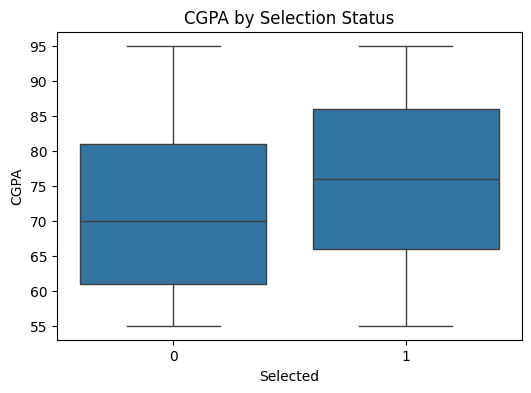

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Selected",y="CGPA")

plt.title("CGPA by Selection Status")

plt.show()

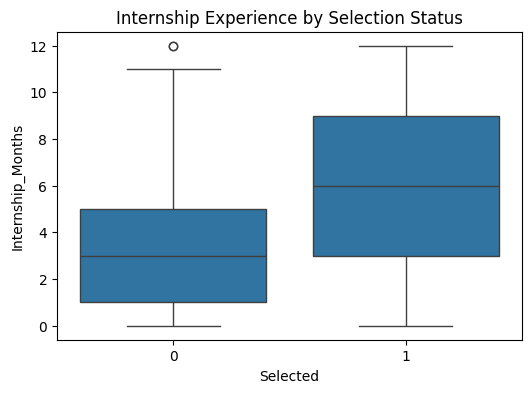

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df,x="Selected",y="Internship_Months")

plt.title("Internship Experience by Selection Status")

plt.show()

Distribution of Candidate CGPA

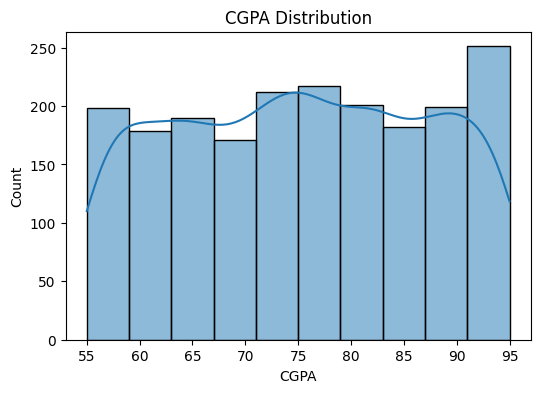

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['CGPA'], bins=10, kde=True)
plt.title("CGPA Distribution")
plt.show()

Correlation Between Numerical Features

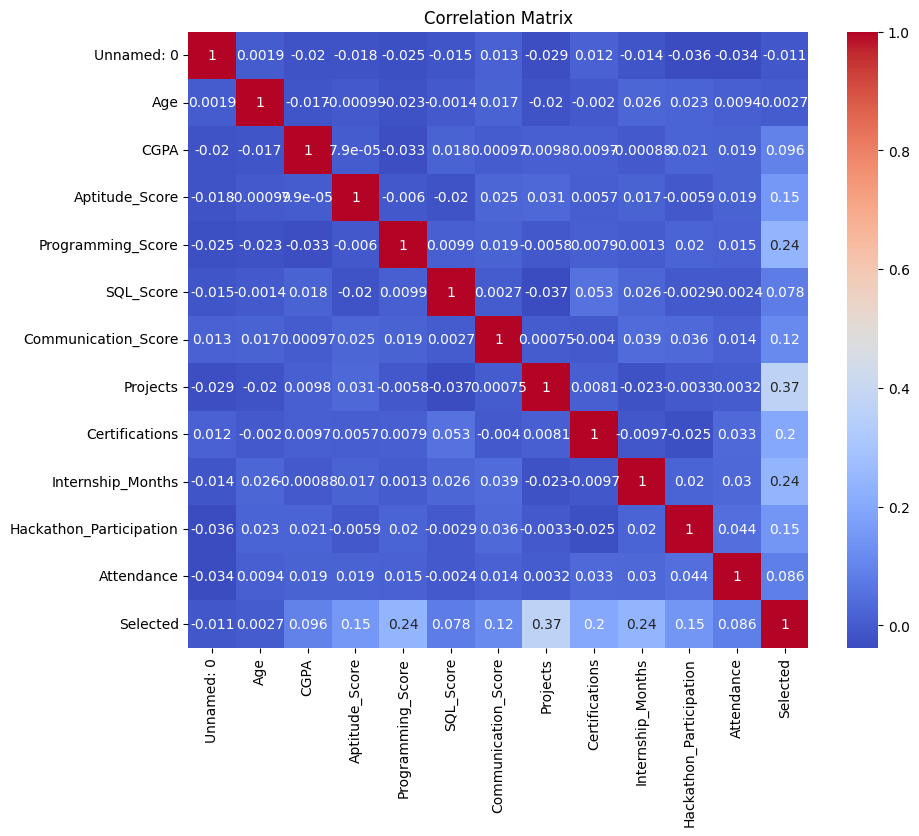

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Data Preprocessing

Check for Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
CGPA,0
Aptitude_Score,0
Programming_Score,0
SQL_Score,0
Communication_Score,0
Projects,0
Certifications,0
Internship_Months,0


Removing Unnecessary Columns

In [ ]:
df = df.drop('Unnamed: 0', axis=1)

Encoding Categorical Variables

In [ ]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

Define Target Variable (y)

In [ ]:
y = df['Selected']

Define Feature Variables (X)

In [ ]:
X = df.drop('Selected', axis=1)

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=2529)
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=2529)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# **Model Selection**

Selected the Random Forest Classifier because:

It provides high prediction accuracy for classification problems.

It can effectively handle multiple numerical features such as CGPA, aptitude score, programming score, and communication score.

It is less prone to overfitting due to the use of multiple decision trees.

Model Training

In [ ]:
model = RandomForestClassifier(random_state=2529)

In [ ]:
model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=2529)

Model Prediction

In [ ]:
y_pred = model.predict(X_test)

Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f} \n Precision: {precision:.2f} \n Recall: {recall:.2f} \n F1 Score: {f1:.2f} \n ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.95 
 Precision: 0.96 
 Recall: 0.98 
 F1 Score: 0.97 
 ROC-AUC: 0.85


Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 37  14]
 [  7 342]]


Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78        51
           1       0.96      0.98      0.97       349

    accuracy                           0.95       400
   macro avg       0.90      0.85      0.87       400
weighted avg       0.95      0.95      0.95       400



# **Explanation**
### This project focuses on predicting whether a fresher candidate will be selected for hiring using machine learning techniques. The dataset was first imported and explored to understand its structure, features, and target variable. Exploratory Data Analysis (EDA) was performed using different visualizations to study the distribution of candidate attributes and identify relationships between various features and the hiring outcome.

### During preprocessing, unnecessary columns were removed, categorical features were converted into numerical values using Label Encoding, and the dataset was checked for missing values before model development. The processed dataset was then divided into training and testing datasets using the train-test split technique.

### A Random Forest Classifier was selected because of its strong performance in classification problems and its ability to handle multiple input features effectively. The model was trained using the training dataset and evaluated on the testing dataset. Performance was measured using Accuracy Score, Confusion Matrix, and Classification Report to assess how well the model classified candidates as selected or not selected.

### Finally, the trained model was used to predict the hiring status of unseen candidates based on their academic performance, technical skills, internship experience, certifications, and other relevant attributes. This project demonstrates how machine learning can support recruitment by providing a faster and more consistent approach to candidate selection.